In [1]:
import math
import threading
import time
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.special import softmax, log_softmax
from sklearn.datasets import fetch_openml
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [2]:
global_seed = 0
global_rng = np.random.default_rng(global_seed)

## Setup

### Global Dataset

In [3]:
mnist = fetch_openml('mnist_784',parser = 'auto')
X = mnist.data
y = mnist.target.astype(int).to_numpy()
C = np.unique(y).shape[0]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=global_seed)

global_preproc = make_pipeline(
    MinMaxScaler(),
    PCA(n_components=0.93, svd_solver="full", random_state=0),
)

X_pca = global_preproc.fit_transform(X_train)
X_aug = np.hstack([X_pca, np.ones((X_pca.shape[0], 1))])
X_pca_test = global_preproc.transform(X_test)
X_aug_test = np.hstack([X_pca_test, np.ones((X_pca_test.shape[0], 1))])

### Global Parameters

In [5]:
alpha_init = 0.3

### Helper Functions

In [6]:
def get_alphas(K):
    return alpha_init / (1.0 + np.arange(K))

In [7]:
def dirichlet_partition(labels, n_clients, alpha):
    labels = np.asarray(labels)
    client_idx = [[] for _ in range(n_clients)]

    for c in np.unique(labels):
        idx_c = np.where(labels == c)[0]
        global_rng.shuffle(idx_c)
        # proportion of class c assigned to each client
        proportions = global_rng.dirichlet(alpha * np.ones(n_clients))
        # split points (cumulative, dropping the last)
        splits = (np.cumsum(proportions)[:-1] * len(idx_c)).astype(int)
        for client, part in enumerate(np.split(idx_c, splits)):
            client_idx[client].extend(part.tolist())

    return [np.array(ci) for ci in client_idx]

In [8]:
def ce_loss(logits, y_true):
    """Mean cross-entropy. logits:(n,K), y_true:(n,) int labels."""
    logp = log_softmax(logits, axis=1)        # stable log-probabilities
    return -logp[np.arange(len(y_true)), y_true].mean()

In [9]:
def global_ce(theta, X, y):
    """Mean softmax cross-entropy; theta shape (d+1, C)."""
    z = X @ theta
    z -= z.max(axis=1, keepdims=True)          # numerical stability
    log_probs = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    return -log_probs[np.arange(len(y)), y].mean()

In [10]:
def sgd_grad(X, y, theta, mu, batch_sz, rng):
    """Stochastic gradient of (1/n)Σ l_i + (mu/2)||theta||^2 on a uniform mini-batch.
       X:(n,d) bias-augmented, theta:(d,K), y:(n,) int, batch:int, rng:np.random.Generator."""
    n, K = X.shape[0], theta.shape[1]
    idx = rng.integers(0, n, size=batch_sz)  # uniform sample
    Xb, yb = X[idx], y[idx]
    Z  = Xb @ theta
    Yb = np.eye(K)[yb]
    loss = -(Yb * log_softmax(Z, axis=1)).sum() / batch_sz + 0.5 * mu * np.linalg.norm(theta)**2
    grad = Xb.T @ (softmax(Z, axis=1) - Yb) / batch_sz + mu * theta
    return loss, grad

In [11]:
def create_graph(num_nodes, b, H, deg=6):
    while True:
        G = nx.random_regular_graph(max(deg, b + 1), num_nodes)
        if nx.node_connectivity(G) > b and nx.is_connected(G.subgraph(H)):
            break
            
    # Metropolis-Hasting weights
    for i in range(num_nodes):
        for j in G.adj[i]:
            if(i != j):
                w_ij = 1/(1+max(G.degree[i], G.degree[j]))
                G.add_edge(i, j, weight= w_ij)
    
    for i in range(num_nodes):
        out_weight_sum = np.sum(np.array([val['weight'] for key,val in G.adj[i].items()]))
        G.add_edge(i,i, weight = 1-out_weight_sum)

    W = nx.to_numpy_array(G)
    
    assert bool(np.sum(W.T @ np.ones(num_nodes)) == num_nodes) and bool(np.sum(np.ones(num_nodes).T @ W) == num_nodes)
    
    return G, W

In [12]:
def proj_tau(x_i, x_j, tau):
    d = x_j - x_i
    nd = np.linalg.norm(d)                # Frobenius for (d+1, C) matrices
    return x_i if nd == 0 else x_i + min(1.0, tau / nd) * d

In [13]:
def rdsgd_constants(W, H, B, gamma_C, X_aug):
    h = len(H)
    Wh = W[np.ix_(H, H)]

    # Effective Mixing Matrix
    Wbar = (1.0 - gamma_C) * Wh
    np.fill_diagonal(Wbar, 0.0)
    np.fill_diagonal(Wbar, 1.0 - Wbar.sum(axis=1))

    # Stationary Distribution 
    pi = np.ones(len(H)) / len(H)
    for _ in range(1500):
        pi = pi @ Wbar
    pi /= pi.sum()

    # lambda_pi: contraction of Wbar on D_pi in the pi-weighted norm.
    # ||M||_pi-op = ||P^{1/2} M P^{-1/2}||_2 with P = diag(pi); restrict to
    # D_pi by composing with the pi-orthogonal projector Pi = I - 1 pi^T.
    sp   = np.sqrt(pi)
    Pi   = np.eye(h) - np.outer(np.ones(h), pi)
    Msim = (sp[:, None] * (Wbar - np.outer(np.ones(h), pi)) @ Pi) / sp[None, :]
    lam_pi = np.linalg.norm(Msim, 2)

    # nu^2_{pi,tot} (Lemma 4 constant)
    w_max = (Wh - np.diag(np.diag(Wh))).max()
    nu2 = 2.0 * (pi.max() / pi.min()) * w_max * gamma_C * (1.0 - gamma_C)

    s2 = (lam_pi**2 + nu2)
    g = 1.0 - s2
    assert s2 < 1.0, "no spectral gap: gamma_C too large for this graph"

    dB_max = max(W[i, B].sum() for i in H) 
    
    return dict(g=g, pi=pi, dB_max=dB_max)

In [14]:
def get_metrics(models, H, mu, X_ref, y_ref, X_te, y_te, pi=None, f_star=None):
    """Head-to-head metrics are evaluated at the UNIFORM average for every
    algorithm. pi is optional and used only for RDSGD theory validation."""
    Hm   = models[H]
    h    = len(H)
    th_u = Hm.mean(0)                     # uniform average == common eval point

    tr_ce = global_ce(th_u, X_ref, y_ref)
    te_ce = global_ce(th_u, X_te,  y_te)
    out = {
        "test_acc":   ((X_te  @ th_u).argmax(1) == y_te ).mean(),
        "train_acc":  ((X_ref @ th_u).argmax(1) == y_ref).mean(),
        "train_ce":   tr_ce,              # unregularized: matches Lemma 12's L
        "test_ce":    te_ce,
        "gap":        te_ce - tr_ce,
        "acc_mean_H": np.mean([((X_te @ Hm[a]).argmax(1) == y_te).mean()
                               for a in range(h)]),
        "dm":         np.mean(np.sum((Hm - th_u)**2, axis=(1, 2))),
        "obj":        tr_ce + 0.5 * mu * np.sum(th_u**2),   # regularized F
    }
    if f_star is not None:
        out["subopt"] = out["obj"] - f_star
    if pi is not None:                    # Theorem 9 lives on x^k_pi
        th_p = np.tensordot(pi, Hm, axes=(0, 0))
        out["test_acc_pi"] = ((X_te @ th_p).argmax(1) == y_te).mean()
    return out

## Byzantine Attacks

In [15]:
def byz_label_flip(i, barrier, models, int_models, alphas):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i) # distinct stream per node
    yl_perm = (yl + rng.integers(0,C)) % C
    for k in range(K):
        loss, g = sgd_grad(Xl, yl_perm, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()
        models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i)))
        barrier.wait()

In [16]:
def byz_sign_flip(i, barrier, models, int_models, alphas, flip_scale=1.0):
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    for k in range(K):
        _, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)   # honest gradient
        int_models[i] = models[i] + flip_scale * alphas[k] * g         # step along -g
        barrier.wait()                                          # (1)
        models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i)))
        barrier.wait()                                          # (2)

In [17]:
def byz_gaussian(i, barrier, models, int_models, alphas, sigma=1.0, around_honest=False):
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    shape = models[i].shape
    for k in range(K):
        if around_honest:                                       # honest + large noise
            _, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
            base = models[i] - alphas[k] * g
        else:                                                   # pure N(0, sigma^2)
            base = 0.0
        int_models[i] = base + sigma * rng.standard_normal(shape)
        barrier.wait()                                          # (1)
        models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i)))
        barrier.wait()                                          # (2)

## Aggregation Rules

In [18]:
def aggregate(i, int_models, W, G, B, H, agg_rule, q_i=None, tau_scc=0.3, q_trim=None):
    """Robust aggregation at honest node i. Returns x^{k+1}_i.
 
    int_models : (num_nodes, d+1, C) half-iterates x^{k+1/2} (Byzantine rows
                 already overwritten with their attack messages).
    q_i        : IOS / Krum   - est. # Byzantine neighbours. Default |B_i|.
    q_trim     : TriMean      - # discarded per tail per coordinate. Default |B_i|.
    tau_scc    : SCC          - clipping radius. Paper uses 0.1 (iid) / 0.3 (non-iid).
    """
    nbrs = [j for j in G.neighbors(i) if j != i]
    if q_i    is None: q_i    = sum(1 for j in nbrs if j in B)
    if q_trim is None: q_trim = sum(1 for j in nbrs if j in B)
    w_ii = W[i, i]
 
    match agg_rule:
        case "IOS":                                       # Alg. 2
            trusted = set(G.neighbors(i))                 # includes i (self-loop)
            def wavg(U):
                return sum(W[i, j] * int_models[j] for j in U) \
                       / sum(W[i, j] for j in U)
            for _ in range(q_i):
                x_avg = wavg(trusted)
                cands = np.array([j for j in trusted if j != i])
                if cands.size == 0: break
                d = np.linalg.norm(int_models[cands] - x_avg, axis=(1, 2))
                trusted.discard(int(cands[d.argmax()]))
            return wavg(trusted)
 
        case "SCC":                                       # eq. (94)
            def _clip(x, tau):
                """CLIP(x, tau) = min(1, tau/||x||) x   (Wu-Chen-Ling eq. 95)."""
                n = np.linalg.norm(x)
                return x if n <= tau or n == 0.0 else (tau / n) * x
            return int_models[i] + sum(
                W[i, j] * _clip(int_models[j] - int_models[i], tau_scc)
                for j in nbrs)
 
        case "TriMean":                                   # eq. (91), App. C
            S = np.stack([int_models[j] for j in nbrs])   # (m, d+1, C)
            m = S.shape[0]
            if 2 * q_trim >= m:
                raise ValueError(f"q_trim={q_trim} too large for {m} neighbours")
            Ssort = np.sort(S, axis=0)
            base = Ssort[q_trim:m - q_trim].mean(0) if q_trim else Ssort.mean(0)
            r = 1.0 / (m + 1 - 2 * q_trim)
            return (1.0 - r) * base + r * int_models[i]
 
        case "Krum":                                      # eq. (10)
            cand = nbrs + [i]
            S = np.stack([int_models[j] for j in cand])
            D = np.linalg.norm(S[:, None] - S[None, :], axis=(2, 3)) ** 2
            k = len(cand) - q_i - 2
            if k < 1:
                raise ValueError(f"Krum needs |S|-q-2 >= 1; got {k}")
            scores = [np.sort(D[a][np.arange(len(cand)) != a])[:k].sum()
                      for a in range(len(cand))]
            base = S[int(np.argmin(scores))]
            return (1.0 - w_ii) * base + w_ii * int_models[i]
 
        case "CooMed":                                    # eq. (8)
            S = np.stack([int_models[j] for j in nbrs])
            return (1.0 - w_ii) * np.median(S, axis=0) + w_ii * int_models[i]

## Byzantine Classifier $\mathcal{C}$

### System Setup

In [19]:
# Parameters
num_nodes = 20
batch_sz = 100
K = 200
mu = 0.2
b = 2
iter_sample_sz = math.floor(K/4)

In [20]:
sampled_iters = global_rng.choice(K, size=iter_sample_sz, replace=False)

dp = dirichlet_partition(y_train, num_nodes, alpha=0.5)

B = global_rng.choice(num_nodes, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
G, W = create_graph(num_nodes, b, H)
alphas = get_alphas(K)

X_H = np.vstack([X_aug[dp[i]] for i in H])
y_H = np.concatenate([y_train[dp[i]] for i in H])

# Shared Variables
barrier = threading.Barrier(num_nodes) 
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
sampled_models = np.zeros((num_nodes, iter_sample_sz, X_pca.shape[1] + 1, C))
sampled_labels = np.zeros((num_nodes, iter_sample_sz, 1))
sampled_feats = np.zeros((num_nodes, len(sampled_iters)*max(dict(G.degree()).values()), 41))

### Feature Engineering

In [21]:
class MatrixSummaryFeatures(BaseEstimator, TransformerMixin):
    """
    Features for incoming neighbor models X: (m, d, C).
    Context (receiver's own model + local labeled batch) enables the
    shift-signature, validation-loss, and prediction-offset features
    that target static class-shift label poisoning.
    """
    def __init__(self, outlier_threshold=3.0):
        self.outlier_threshold = outlier_threshold
        self.theta_ref_ = None      # (d, C) receiver's current model
        self.X_local_  = None       # (n_loc, d) local (augmented) features
        self.y_local_  = None       # (n_loc,)  local labels

    def set_context(self, theta_ref, X_local, y_local):
        self.theta_ref_ = np.asarray(theta_ref)
        self.X_local_   = np.asarray(X_local)
        self.y_local_   = np.asarray(y_local)
        return self

    def fit(self, X, y=None):
        return self

    # ---------- helpers ----------
    @staticmethod
    def _softmax_ce(logits, y):
        # logits: (n, C); stable mean cross-entropy
        z = logits - logits.max(axis=1, keepdims=True)
        log_p = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
        return -log_p[np.arange(len(y)), y].mean()

    @staticmethod
    def _shift_scores(theta_i, theta_j, eps=1e-12):
        # cosine-normalized class-alignment matrix, scored per cyclic shift
        A = theta_i.T @ theta_j                                    # (C, C)
        A /= (np.linalg.norm(theta_i, axis=0)[:, None]
            * np.linalg.norm(theta_j, axis=0)[None, :] + eps)
        C = A.shape[0]
        return np.array([np.mean(np.diag(np.roll(A, -s, axis=1)))
                         for s in range(C)])                       # (C,)

    # ---------- transform ----------
    def transform(self, X):
        if X.ndim == 2:
            X = X.reshape(1, X.shape[0], X.shape[1])
        m, d, C = X.shape
        eps = 1e-12

        # 1. Column-norm ratios ------------------------------------
        col_norms = np.linalg.norm(X, axis=1)                      # (m, C)
        norm_ratios = col_norms / (np.median(col_norms, axis=1,
                                             keepdims=True) + eps)

        # 2. Cosine to median direction ----------------------------
        median_dir = np.median(X, axis=2)                          # (m, d)
        median_dir /= (np.linalg.norm(median_dir, axis=1,
                                      keepdims=True) + eps)
        cos_angles = np.einsum('mdc,md->mc', X, median_dir) / (col_norms + eps)

        # 3. Coordinate-wise outlier fractions ---------------------
        row_med = np.median(X, axis=2, keepdims=True)
        row_mad = np.median(np.abs(X - row_med), axis=2, keepdims=True)
        z = 0.6745 * (X - row_med) / (row_mad + eps)
        out_frac = np.mean(np.abs(z) > self.outlier_threshold, axis=2)  # (m, d)
        outlier_summary = np.stack([out_frac.mean(axis=1),
                                    out_frac.max(axis=1)], axis=1)      # (m, 2)

        blocks = [norm_ratios, cos_angles, outlier_summary]

        # 4-6. Context-dependent features --------------------------
        if self.theta_ref_ is not None:
            th_i = self.theta_ref_
            Xl, yl = self.X_local_, self.y_local_
            logits_i = Xl @ th_i                                   # (n_loc, C)
            pred_i   = logits_i.argmax(axis=1)
            ce_i     = self._softmax_ce(logits_i, yl)

            shift_feats, loss_feats, offset_feats = [], [], []
            for j in range(m):
                th_j = X[j]

                # 4. Shift signature (matched filter for cyclic relabeling)
                s = self._shift_scores(th_i, th_j)                 # (C,)
                s_hat = int(np.argmax(s))
                shift_feats.append(np.concatenate([
                    s,                                             # full profile (C,)
                    [s[s_hat] - s[0],                              # margin over identity
                     float(s_hat != 0)]                            # non-identity flag
                ]))

                # 5. Local validation loss
                logits_j = Xl @ th_j
                ce_j  = self._softmax_ce(logits_j, yl)
                acc_j = (logits_j.argmax(axis=1) == yl).mean()
                loss_feats.append([ce_j,
                                   ce_j - ce_i,                    # excess CE vs own model
                                   acc_j])

                # 6. Prediction-offset histogram
                offs = (logits_j.argmax(axis=1) - pred_i) % C
                hist = np.bincount(offs, minlength=C) / len(offs)  # (C,)
                p = hist + eps
                peak = int(np.argmax(hist))
                offset_feats.append([hist[0],                      # agreement mass
                                     hist.max(),                   # peak concentration
                                     float(peak != 0),             # peak off identity
                                     -(p * np.log(p)).sum()])      # entropy

            blocks += [np.array(shift_feats),                      # (m, C+2)
                       np.array(loss_feats),                       # (m, 3)
                       np.array(offset_feats)]                     # (m, 4)

        return np.concatenate(blocks, axis=1)   # (m, 2C+2) or (m, 3C+11) with context

In [22]:
norm_cols    = list(range(0, C))                   # norm ratios
angle_cols   = list(range(C, 2*C))                 # cosines to median dir
outlier_cols = list(range(2*C, 2*C + 2))           # outlier fractions
shift_prof   = list(range(2*C + 2, 3*C + 2))       # shift-score profile (C)
shift_stats  = [3*C + 2, 3*C + 3]                  # margin, non-identity flag
loss_cols    = [3*C + 4, 3*C + 5, 3*C + 6]         # ce_j, ce_j - ce_i, acc_j
offset_cols  = [3*C + 7, 3*C + 8, 3*C + 9, 3*C + 10]  # hist[0], peak, flag, entropy

binary_cols  = [3*C + 3, 3*C + 9]                  # the two indicator flags
scaled_robust = angle_cols + shift_prof + [3*C + 2] + loss_cols
scaled_std    = norm_cols + outlier_cols + [3*C + 7, 3*C + 8, 3*C + 10]

In [23]:
feat_pre_proc = ColumnTransformer([
    ('redundant', make_pipeline(StandardScaler(),
                                PCA(n_components=0.93, svd_solver='full',
                                    random_state=0)),
                  norm_cols + angle_cols + shift_prof),
    ('robust', RobustScaler(), [3*C + 2] + loss_cols),
    ('std',    StandardScaler(), outlier_cols + [3*C + 7, 3*C + 8, 3*C + 10]),
    ('flags',  'passthrough', binary_cols),
])

### Multithreaded Worker Setup

In [24]:
results = [None] * num_nodes
def worker_DSGD_sampling(i, barrier, tar_node, models, int_models, sampled_feats, sampled_labels, alphas):
    cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    feat = MatrixSummaryFeatures(outlier_threshold=3.0)   # own instance
    nbrs = list(G.neighbors(i))
    feats, labels = [], []
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()                       # (1)

        if k in sampled_iters:
            feat.set_context(models[i], Xl, yl)
            Z = feat.transform(np.stack([int_models[j] for j in nbrs]))
            feats.append(Z)
            labels.extend(int(j in B) for j in nbrs)
            
        # oracle-filtered mixing with renormalization (mass to self-loop)
        w_self = W[i, i] + sum(W[i, j] for j in nbrs if j in B)
        models[i] = w_self * int_models[i] + sum(
            W[i, j] * int_models[j] for j in nbrs if j in H)
        barrier.wait()                       # (2)
    results[i] = (np.concatenate(feats), np.array(labels))

In [25]:
# Run Setup
tar_node = global_rng.choice(H)
models.fill(0)
int_models.fill(0)

hon_threads = [threading.Thread(target=worker_DSGD_sampling, 
                                   args=(i, barrier, tar_node, models, int_models, sampled_feats, sampled_labels, alphas,)) for i in H]
byz_threads = [threading.Thread(target=byz_label_flip, args=(i, barrier, models, int_models, alphas,)) for i in B]
threads = hon_threads + byz_threads

for thread in threads:
    thread.start()
    
for thread in threads:
    thread.join()

### Data Preprocessing

In [26]:
X_C_raw = np.concatenate([results[i][0] for i in H])
y_C = np.concatenate([results[i][1] for i in H])
X_C_raw_train, X_C_raw_test, y_C_train, y_C_test = train_test_split(X_C_raw, y_C, test_size=0.33, shuffle=True, random_state=global_seed)
X_C_train = feat_pre_proc.fit_transform(X_C_raw_train)

### Training and Evaluation

In [27]:
warnings.simplefilter("ignore")
lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=global_seed)
grid = GridSearchCV(lr_clf, param_grid={'C': [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_C_train, y_C_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [28]:
# Evaluate on test set
X_C_test = feat_pre_proc.transform(X_C_raw_test)
y_C_pred = grid.best_estimator_.predict(X_C_test)
y_C_proba = grid.best_estimator_.predict_proba(X_C_test)[:, 1]
print("\nTest set results:")
print(f"Accuracy : {accuracy_score(y_C_test, y_C_pred):.4f}")
print(f"Recall   : {recall_score(y_C_test, y_C_pred):.4f}")
print(f"F1       : {f1_score(y_C_test, y_C_pred):.4f}")
print(f"ROC‑AUC  : {roc_auc_score(y_C_test, y_C_proba):.4f}")


Test set results:
Accuracy : 0.9779
Recall   : 0.8545
F1       : 0.8910
ROC‑AUC  : 0.9793


In [29]:
fpr, tpr, thr = roc_curve(y_C_test, y_C_proba)
i = np.searchsorted(fpr, 0.1, side='right') - 1
C_fpr = fpr[i]
C_fnr = 1-tpr[i]
C_tau = thr[i]
print(f"tau={thr[i]:.4f}, FPR={fpr[i]:.3f}, FNR={1-tpr[i]:.3f}")

tau=0.3275, FPR=0.099, FNR=0.091


## Projection Constant $c$ in $\tau=c\alpha$

In [30]:
# Parameters
num_nodes = 20
batch_sz = 100
K = 200
mu = 0.2
b = 2
eta = 1.2

In [31]:
dp = dirichlet_partition(y_train, num_nodes, alpha=0.5)

B = global_rng.choice(num_nodes, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
G, W = create_graph(num_nodes, b, H)
alphas = get_alphas(K)

X_H = np.vstack([X_aug[dp[i]] for i in H])
y_H = np.concatenate([y_train[dp[i]] for i in H])

# Shared Variables
barrier = threading.Barrier(num_nodes) 
tar_node = global_rng.integers(0,num_nodes)
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
r_samples = [[] for _ in range(num_nodes)]

In [32]:
def worker_DSGD_proj(i, barrier, tar_node, models, int_models, alphas, r_samples):
    cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    nbors = np.array([j for j in G.neighbors(i) if j != i])
    hon_nbors = [j for j in nbors if j in H]
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()
        r_samples[i].extend(np.linalg.norm(int_models[j] - models[i]) / alphas[k] for j in hon_nbors)
        barrier.wait()

In [33]:
# Run Setup
models.fill(0)
int_models.fill(0)

DSGD_threads = [threading.Thread(target=worker_DSGD_proj, 
                                 args=(i, barrier, tar_node, models, int_models, alphas, r_samples,))
                for i in np.arange(num_nodes)]

for thread in DSGD_threads:
    thread.start()
for thread in DSGD_threads:
    thread.join()

In [34]:
r = np.concatenate([np.asarray(s) for i, s in enumerate(r_samples) if i in H])
proj_const = eta * np.quantile(r, 0.99)
# taus = proj_const * alphas

## Byzantine-Robust DSGD

### System Setup

In [51]:
# Parameters
num_nodes = 20
batch_sz = 100
b = 2
tau_log = 0.5
K = 200
logging_freq = 10

In [52]:
dp = dirichlet_partition(y_train, num_nodes, alpha=0.5)

B = global_rng.choice(num_nodes, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
G, W = create_graph(num_nodes, b, H)
alphas = get_alphas(K)
taus = proj_const * alphas

X_H = np.vstack([X_aug[dp[i]] for i in H])
y_H = np.concatenate([y_train[dp[i]] for i in H])

# Shared Objects
barrier = threading.Barrier(num_nodes) 
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))

### Algorithms

In [53]:
def worker_RDSGD(i, barrier, models, int_models, tar_node, tar_metrics, pre_pipe, best_est, tau_log, alphas):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    feat = MatrixSummaryFeatures(outlier_threshold=3.0)
    nbors = np.array([j for j in G.neighbors(i) if j != i])
    
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g       # local step
        barrier.wait()                           # (1) everyone wrote int_models[*]

        feat.set_context(models[i], Xl, yl)
        Z = feat.transform(np.stack([int_models[j] for j in nbors]))
        nbor_int_models = feat_pre_proc.transform(Z)
        nbor_byz_filt = best_est.predict_proba(nbor_int_models)[:,1] > tau_log
        # assert(nbor_byz_filt.shape == nbors.shape)

        w_row = W[i].copy()
        w_row[nbors[nbor_byz_filt]] = 0.0
        w_row[i] = 1.0 - w_row[nbors].sum()
        models[i] = sum(w_row[j] * proj_tau(models[i], int_models[j], taus[k]) for j in np.append(nbors, i))
        barrier.wait()
        
        if(i == tar_node):
            metrics = get_metrics(models, H, mu, X_H, y_H, X_aug_test, y_test)
            if(k % logging_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            tar_metrics.append(metrics)        

In [54]:
def worker_AGG(i, barrier, models, int_models, tar_node, tar_metrics, alphas, agg_rule):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    nbors = np.array([j for j in G.neighbors(i) if j != i])
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g 
        barrier.wait()
        models[i] = aggregate(i, int_models, W, G, B, H, agg_rule)
        barrier.wait()
        if(i == tar_node):
            metrics = get_metrics(models, H, mu, X_H, y_H, X_aug_test, y_test)
            if(k % logging_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            tar_metrics.append(metrics)

### Byzantine-Free (T0)

In [55]:
# Run Setup
tar_metrics = {'RDSGD': list(), 
               'CooMed': list(),
               'SCC': list(),
               'Krum': list(),
               'TriMean': list(),
               'IOS': list()}
tar_node = global_rng.integers(0,num_nodes)
B_saved = B
B = [] # remove Byzantines

RDSGD_threads = [threading.Thread(target=worker_RDSGD, 
                                  args=(i, barrier, models, int_models, tar_node, tar_metrics['RDSGD'],
                                        feat_pre_proc, grid.best_estimator_, C_tau, alphas))
                for i in np.arange(num_nodes)]
IOS_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['IOS'], alphas, "IOS",))
                for i in np.arange(num_nodes)]
CooMed_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['CooMed'], alphas, "CooMed",))
                for i in np.arange(num_nodes)]
TriMean_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['TriMean'], alphas, "TriMean",))
                for i in np.arange(num_nodes)]
SCC_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['SCC'], alphas, "SCC",))
                for i in np.arange(num_nodes)]
Krum_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['Krum'], alphas, "Krum",))
                for i in np.arange(num_nodes)]
alg_threads = {'RDSGD': RDSGD_threads, 
               'IOS': IOS_threads, 
               # 'Krum': Krum_threads, 
               'SCC': SCC_threads,
               'TriMean': TriMean_threads,
               'CooMed': CooMed_threads}

for [alg,threads] in alg_threads.items():
    models.fill(0)
    int_models.fill(0)

    strlen_print = 30 - (len(alg)+2)
    print((strlen_print//2)*"=" + f" {alg} " + (strlen_print//2)*"=")
    for t in threads:
        t.start()
    for t in threads:
        t.join()

=========== RDSGD ===========
[k=10] train_loss=1.6227
[k=20] train_loss=1.5447
[k=30] train_loss=1.5030
[k=40] train_loss=1.4755
[k=50] train_loss=1.4554
[k=60] train_loss=1.4395
[k=70] train_loss=1.4266
[k=80] train_loss=1.4157
[k=90] train_loss=1.4064
[k=100] train_loss=1.3983
[k=110] train_loss=1.3912
[k=120] train_loss=1.3848
[k=130] train_loss=1.3790
[k=140] train_loss=1.3738
[k=150] train_loss=1.3690
[k=160] train_loss=1.3646
[k=170] train_loss=1.3604
[k=180] train_loss=1.3566
[k=190] train_loss=1.3530
============ IOS ============
[k=10] train_loss=1.6229
[k=20] train_loss=1.5449
[k=30] train_loss=1.5033
[k=40] train_loss=1.4758
[k=50] train_loss=1.4557
[k=60] train_loss=1.4398
[k=70] train_loss=1.4269
[k=80] train_loss=1.4160
[k=90] train_loss=1.4067
[k=100] train_loss=1.3986
[k=110] train_loss=1.3915
[k=120] train_loss=1.3851
[k=130] train_loss=1.3794
[k=140] train_loss=1.3741
[k=150] train_loss=1.3693
[k=160] train_loss=1.3649
[k=170] train_loss=1.3607
[k=180] train_loss=1.3

In [56]:
df = pd.concat(
    {alg:pd.DataFrame(metric) for [alg,metric] in tar_metrics.items()},
    names=["alg", "k"],
)

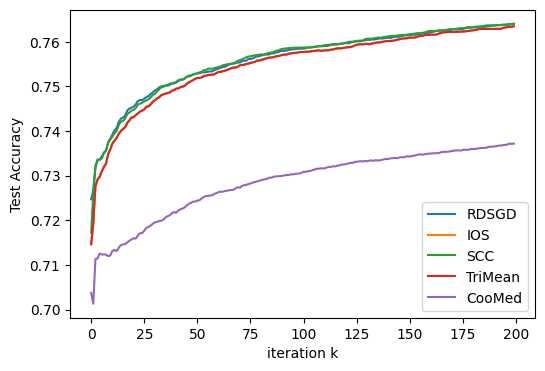

In [57]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
iter_idx = np.arange(K)
for [alg,_] in alg_threads.items():
    ax.plot(iter_idx, df.loc[alg]['test_acc'], label=alg)
ax.set_xlabel('iteration k')
ax.set_ylabel('Test Accuracy')
ax.legend()
plt.show()

### Byzantine (T3)

In [58]:
# Run Setup
tar_metrics = {'RDSGD': list(), 
               'CooMed': list(),
               'SCC': list(),
               'TriMean': list(),
               'Krum': list(),
               'IOS': list()}
tar_node = global_rng.choice(H)
B=B_saved # restore Byzantines

RDSGD_threads = [threading.Thread(target=worker_RDSGD, 
                                  args=(i, barrier, models, int_models, tar_node, tar_metrics['RDSGD'],
                                        feat_pre_proc, grid.best_estimator_, C_tau, alphas))
                for i in H]
IOS_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['IOS'], alphas, "IOS",))
                for i in H]
CooMed_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['CooMed'], alphas, "CooMed",))
                for i in H]
TriMean_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['TriMean'], alphas, "TriMean",))
                for i in H]
SCC_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['SCC'], alphas, "SCC",))
                for i in H]
Krum_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['Krum'], alphas, "Krum",))
                for i in np.arange(num_nodes)]
alg_threads = {'RDSGD': RDSGD_threads, 
               'IOS': IOS_threads, 
               'SCC': SCC_threads,
               # 'Krum': Krum_threads,
               'TriMean': TriMean_threads,
               'CooMed': CooMed_threads}

for [alg,hon_threads] in alg_threads.items():
    models.fill(0)
    int_models.fill(0)
    byz_threads = [threading.Thread(target=byz_label_flip, args=(i, barrier, models, int_models, alphas)) for i in B]
    threads = hon_threads + byz_threads

    strlen_print = 30 - (len(alg)+2)
    print((strlen_print//2)*"=" + f" {alg} " + (strlen_print//2)*"=")
    for t in threads:
        t.start()
    for t in threads:
        t.join()

=========== RDSGD ===========
[k=10] train_loss=1.6380
[k=20] train_loss=1.5604
[k=30] train_loss=1.5193
[k=40] train_loss=1.4925
[k=50] train_loss=1.4722
[k=60] train_loss=1.4561
[k=70] train_loss=1.4426
[k=80] train_loss=1.4313
[k=90] train_loss=1.4216
[k=100] train_loss=1.4131
[k=110] train_loss=1.4056
[k=120] train_loss=1.3988
[k=130] train_loss=1.3927
[k=140] train_loss=1.3872
[k=150] train_loss=1.3822
[k=160] train_loss=1.3775
[k=170] train_loss=1.3732
[k=180] train_loss=1.3692
[k=190] train_loss=1.3654
============ IOS ============
[k=10] train_loss=1.6331
[k=20] train_loss=1.5547
[k=30] train_loss=1.5117
[k=40] train_loss=1.4833
[k=50] train_loss=1.4625
[k=60] train_loss=1.4461
[k=70] train_loss=1.4328
[k=80] train_loss=1.4216
[k=90] train_loss=1.4120
[k=100] train_loss=1.4037
[k=110] train_loss=1.3963
[k=120] train_loss=1.3897
[k=130] train_loss=1.3838
[k=140] train_loss=1.3784
[k=150] train_loss=1.3734
[k=160] train_loss=1.3688
[k=170] train_loss=1.3646
[k=180] train_loss=1.3

In [59]:
df = pd.concat(
    {alg:pd.DataFrame(metric) for [alg,metric] in tar_metrics.items()},
    names=["alg", "k"],
)

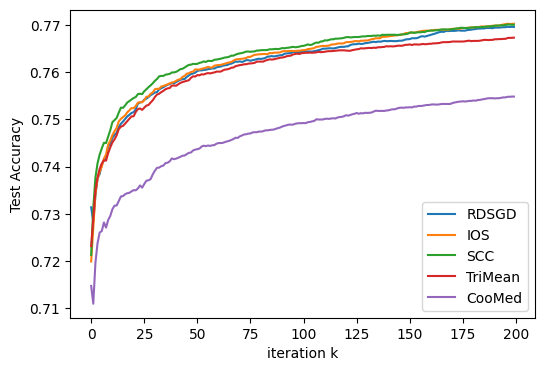

In [60]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
iter_idx = np.arange(K)
for [alg,_] in alg_threads.items():
    ax.plot(iter_idx, df.loc[alg]['test_acc'], label=alg)
ax.set_xlabel('iteration k')
ax.set_ylabel('Test Accuracy')
ax.legend()
plt.show()

## Baselines

### Attack-free DSGD

In [62]:
def worker_DSGD(i, tar_node, tar_metrics, models, int_models, alphas):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], mu, batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()       
        models[i] = sum(W[i, j] * int_models[j] for j in G.neighbors(i))
        barrier.wait()
            
        if(i == tar_node):
            metrics = get_metrics(models, H, mu, X_H, y_H, X_aug_test, y_test)
            if(k % logging_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            tar_metrics.append(metrics)

In [63]:
# Run Setup
tar_metrics = list()
tar_node = global_rng.integers(0, num_nodes)
models.fill(0)
int_models.fill(0)

DSGD_threads = [threading.Thread(target=worker_DSGD, 
                                 args=(i, tar_node, tar_metrics, models, int_models, alphas)) 
                for i in np.arange(num_nodes)]

for t in DSGD_threads:
    t.start()
for t in DSGD_threads:
    t.join()

[k=10] train_loss=1.6229
[k=20] train_loss=1.5449
[k=30] train_loss=1.5033
[k=40] train_loss=1.4758
[k=50] train_loss=1.4557
[k=60] train_loss=1.4398
[k=70] train_loss=1.4269
[k=80] train_loss=1.4160
[k=90] train_loss=1.4067
[k=100] train_loss=1.3986
[k=110] train_loss=1.3915
[k=120] train_loss=1.3851
[k=130] train_loss=1.3794
[k=140] train_loss=1.3741
[k=150] train_loss=1.3693
[k=160] train_loss=1.3649
[k=170] train_loss=1.3607
[k=180] train_loss=1.3569
[k=190] train_loss=1.3534


In [64]:
df = pd.DataFrame(tar_metrics)

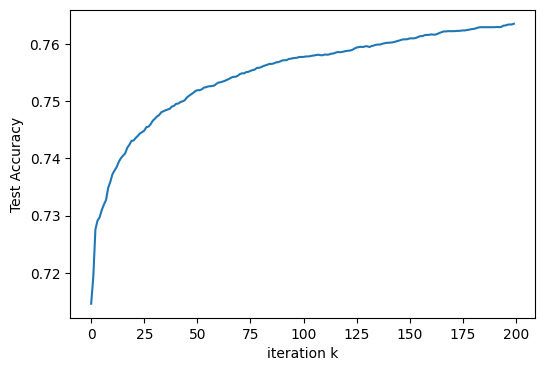

In [65]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
iter_idx = np.arange(K)
ax.plot(iter_idx, df['test_acc'])
ax.set_xlabel('iteration k')
ax.set_ylabel('Test Accuracy')
plt.show()

### Local Compute 

In [49]:
full_pipe = make_pipeline(
    global_preproc,
    StandardScaler(),
    LogisticRegression(
        C=5, # 1/mu
        l1_ratio=0,
        solver='lbfgs',
        max_iter=1000,
        random_state=global_seed
    )
)

In [50]:
full_pipe.fit(X_train, y_train)
y_pred = full_pipe.predict(X_test)
y_proba = full_pipe.predict_proba(X_test)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")

Test Accuracy : 0.9171
